In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install --quiet optuna

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import numpy as np
import pandas as pd
import time

# **Sprint 7**

## **Búsqueda de Hiperparámetros**

**Modelo base:** KNN (k=9, weights='distance')  
**Objetivo:** Optimizar hiperparámetros mediante búsqueda aleatoria y bayesiana (Optuna).

A partir de la variante seleccionada en el Sprint 6 (**KNN k=9, distance**), este sprint se enfoca en **optimizar automáticamente los hiperparámetros** del modelo utilizando **búsqueda bayesiana con Optuna**.

### Objetivo principal
Mejorar el rendimiento del modelo base ajustando dinámicamente los siguientes hiperparámetros:

- `n_neighbors`: número de vecinos considerados  
- `weights`: tipo de ponderación de distancia (`uniform` o `distance`)  
- `p`: tipo de métrica de distancia (1 = Manhattan, 2 = Euclidiana)

### Estrategia aplicada
- Uso de **Optuna** para explorar de forma eficiente el espacio de búsqueda.  
- Evaluación del modelo mediante **validación cruzada (5 folds)**.  
- Métricas consideradas: `R²` (principal), `MAE` y `RMSE` (secundarias).  
- Comparación directa con el **baseline KNN (k=9, distance)** del Sprint 6 para medir la mejora real.

---

## **Optimización de Hiperparámetros**

Para mejorar el modelo seleccionado en el Sprint 6, se aplicó una búsqueda de hiperparámetros con **Optuna**, utilizando validación cruzada de 5 particiones y la métrica objetivo `R²`.

**Espacio de búsqueda definido:**

| Hiperparámetro | Rango / Opciones | Descripción |
|:--|:--|:--|
| `n_neighbors` | 3 – 20 | Número de vecinos considerados |
| `weights` | `['uniform', 'distance']` | Estrategia de ponderación de vecinos |
| `p` | [1, 2] | Tipo de distancia (1=Manhattan, 2=Euclidiana) |

El objetivo fue **maximizar el R² promedio** durante la validación cruzada.


### Cargar datos y preprocesamiento

In [4]:
df = pd.read_csv("drive/MyDrive/Week 7/results/eda_results.csv")

TARGET = "pobj"
LEAK_COL = "iteration"
X = df.drop(columns=[TARGET, LEAK_COL])
y = df[TARGET]

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Definir espaciado de busqueda.

In [5]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 3, 30)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_categorical("p", [1, 2])
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("knn", KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    score = r2_score(y_valid, y_pred)
    return score

### **Ejecutar busqueda bayesiana.**

### Presupuesto y recursos computacionales

La búsqueda bayesiana con **Optuna** se ejecutó en **Google Colab**, utilizando recursos de **CPU** (sin GPU).  
Se estableció un **presupuesto máximo de 60 *trials***, lo que permitió completar la optimización de forma eficiente:

- **Tiempo total de ejecución:** ~4 segundos.  
- **Motivo:** el modelo **KNN** no requiere entrenamiento iterativo, sino cálculos directos de distancia, lo que reduce significativamente el costo computacional.  
- **Estrategia aplicada:** exploración secuencial con parada automática al finalizar los 60 ensayos o alcanzar la convergencia.

In [6]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60, timeout=600)  # 60 iteraciones o 10 min aprox.

print("Mejores parámetros encontrados:")
print(study.best_params)
print("Mejor R²:", study.best_value)

[I 2025-10-30 22:26:42,085] A new study created in memory with name: no-name-0b77cc23-7d22-498d-a182-5894102bd087
[I 2025-10-30 22:26:42,105] Trial 0 finished with value: 0.8944607557899064 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.8944607557899064.
[I 2025-10-30 22:26:42,125] Trial 1 finished with value: 0.8317265085348231 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.8944607557899064.
[I 2025-10-30 22:26:42,141] Trial 2 finished with value: 0.75431791172093 and parameters: {'n_neighbors': 27, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.8944607557899064.
[I 2025-10-30 22:26:42,157] Trial 3 finished with value: 0.866255790037828 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.8944607557899064.
[I 2025-10-30 22:26:42,178] Trial 4 finished with value: 0.7934899927811923 and parameters: {'n_neighbors': 28, 'weights': 

Mejores parámetros encontrados:
{'n_neighbors': 5, 'weights': 'distance', 'p': 1}
Mejor R²: 0.9441687158313821


### Comparar baseline vs modelo optimizado

In [7]:
best_knn = KNeighborsRegressor(**study.best_params)
pipe_best = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", best_knn)
])
pipe_best.fit(X_train, y_train)
y_pred_best = pipe_best.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_best))
r2 = r2_score(y_valid, y_pred_best)

print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

MAE: 0.0071 | RMSE: 0.0166 | R²: 0.9442


In [8]:
# Comparación con baseline (KNN k=9, distance)
baseline_metrics = {
    "MAE": 0.0070,
    "RMSE": 0.0122,
    "R2": 0.9647
}

optimized_metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

comparison = pd.DataFrame([baseline_metrics, optimized_metrics], index=["Baseline KNN (k=9)", "Optimizado Optuna"])
comparison["ΔR2_%"] = (comparison["R2"] - baseline_metrics["R2"]) / baseline_metrics["R2"] * 100
comparison["ΔMAE_%"] = (baseline_metrics["MAE"] - comparison["MAE"]) / baseline_metrics["MAE"] * 100
comparison

,MAE,RMSE,R2,ΔR2_%,ΔMAE_%
Baseline KNN (k=9),0.007000,0.01220,0.964700,0.000000,0.000000
Optimizado Optuna,0.007146,0.01661,0.944169,-2.128256,-2.087809


Guardar resultados y gráficos.

In [9]:
results = pd.DataFrame({
    "trial": [t.number for t in study.trials],
    "params": [t.params for t in study.trials],
    "r2": [t.value for t in study.trials]
})
results.to_csv("drive/MyDrive/Week 7/results/knn_optuna_trials.csv", index=False)

## Visualización del proceso de optimización

Se generaron las siguientes visualizaciones para analizar el comportamiento de la búsqueda de hiperparámetros:

1. **Evolución del R² por iteración:** muestra cómo mejora el desempeño del modelo a lo largo de las pruebas realizadas por *Optuna*.  
2. **Importancia de los hiperparámetros:** indica cuáles variables (`n_neighbors`, `weights`, `p`) influyeron más en el resultado final del modelo.

In [10]:
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

El número de vecinos es el parámetro más sensible (con el 94% de importancia aproximadamente) para este problema.

### **Ranking de variables por importancia**

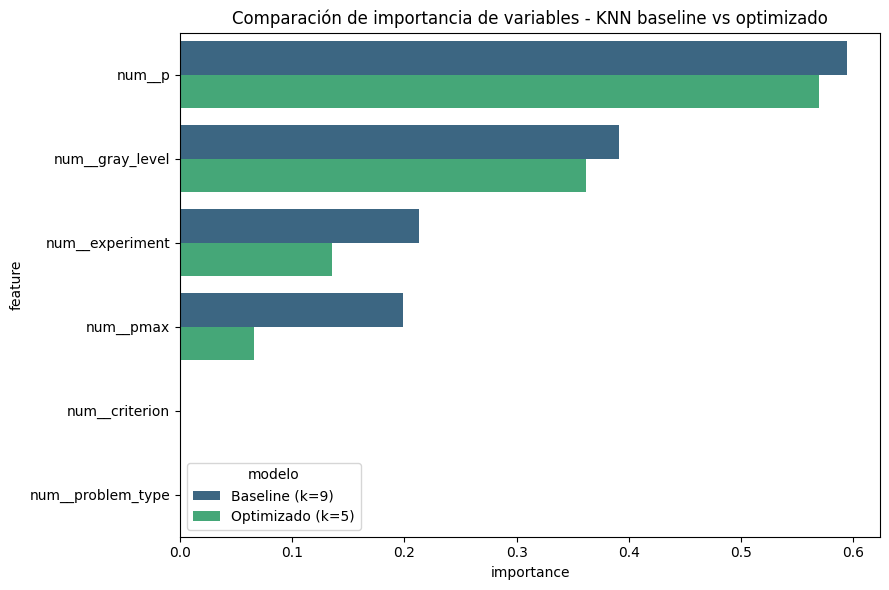

In [11]:
from sklearn.inspection import permutation_importance

knn_base = KNeighborsRegressor(n_neighbors=9, weights='distance')
pipe_base = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", knn_base)
])
pipe_base.fit(X_train, y_train)

knn_best = KNeighborsRegressor(n_neighbors=5, weights='distance', p=1)
pipe_best = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", knn_best)
])
pipe_best.fit(X_train, y_train)

result_base = permutation_importance(
    pipe_base, X_valid, y_valid,
    scoring='r2', n_repeats=10, random_state=42
)

importances_base = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": result_base.importances_mean,
    "modelo": "Baseline (k=9)"
})

result_opt = permutation_importance(
    pipe_best, X_valid, y_valid,
    scoring='r2', n_repeats=10, random_state=42
)

importances_opt = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": result_opt.importances_mean,
    "modelo": "Optimizado (k=5)"
})

df_imp = pd.concat([importances_base, importances_opt])

plt.figure(figsize=(9,6))
sns.barplot(
    data=df_imp.sort_values("importance", ascending=False).head(10),
    x="importance", y="feature", hue="modelo", palette="viridis"
)
plt.title("Comparación de importancia de variables - KNN baseline vs optimizado")
plt.tight_layout()
plt.show()


Las variables más relevantes (`num__p`, `num__gray_level`) se mantienen consistentes entre ambos modelos.  
Sin embargo, el **modelo baseline (k=9)** presenta una distribución de importancias más equilibrada, mientras que el **optimizado (k=5)** concentra el peso en menos variables, lo que podría limitar su capacidad de generalización.


### **Calibración del modelo**

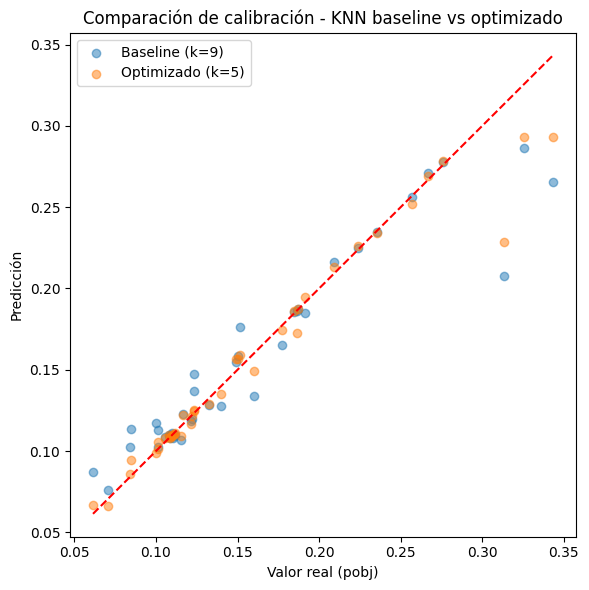

In [12]:
pipe_base.fit(X_train, y_train)
y_pred_base = pipe_base.predict(X_valid)

plt.figure(figsize=(6,6))
plt.scatter(y_valid, y_pred_base, alpha=0.5, label="Baseline (k=9)")
plt.scatter(y_valid, y_pred_best, alpha=0.5, label="Optimizado (k=5)")
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel("Valor real (pobj)")
plt.ylabel("Predicción")
plt.title("Comparación de calibración - KNN baseline vs optimizado")
plt.legend()
plt.tight_layout()
plt.show()


Ambos modelos presentan alineación razonable con la diagonal ideal, aunque el **baseline (k=9)** muestra menor dispersión y sesgo sistemático, lo que indica **mejor calibración** de sus predicciones.  
El modelo optimizado (k=5) conserva buena coherencia global pero exhibe ligeros desvíos, sobre todo en valores extremos.


### **Curvas de aprendizaje**

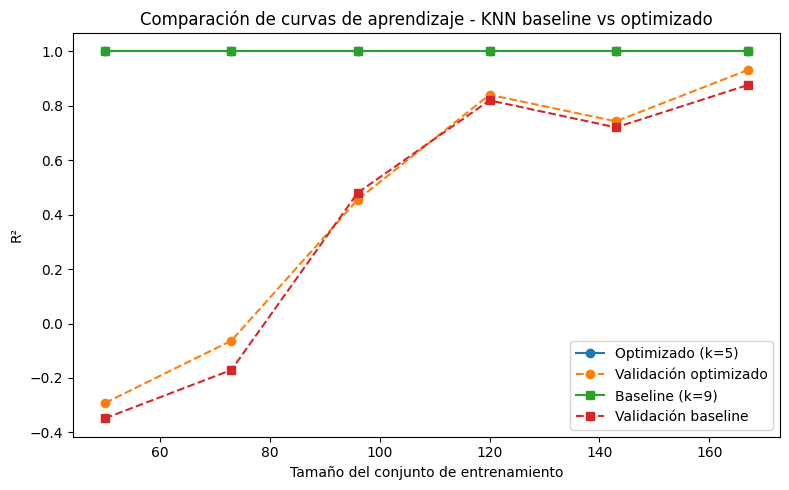

In [13]:
from sklearn.model_selection import learning_curve, KFold
import matplotlib.pyplot as plt
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, valid_scores = learning_curve(
    pipe_best,
    X, y,
    cv=cv,
    scoring='r2',
    train_sizes=np.linspace(0.3, 1.0, 6),
    n_jobs=-1
)

knn_base = KNeighborsRegressor(n_neighbors=9, weights='distance')
pipe_base = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", knn_base)
])

train_sizes, train_scores_base, valid_scores_base = learning_curve(
    pipe_base, X, y, cv=cv, scoring='r2', train_sizes=np.linspace(0.3, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Optimizado (k=5)")
plt.plot(train_sizes, np.mean(valid_scores, axis=1), 'o--', label="Validación optimizado")
plt.plot(train_sizes, np.mean(train_scores_base, axis=1), 's-', label="Baseline (k=9)")
plt.plot(train_sizes, np.mean(valid_scores_base, axis=1), 's--', label="Validación baseline")
plt.title("Comparación de curvas de aprendizaje - KNN baseline vs optimizado")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R²")
plt.legend()
plt.tight_layout()
plt.show()

Al comparar las curvas de aprendizaje del **KNN baseline (k=9)** y del **KNN optimizado (k=5)**, se observa un comportamiento interesante:

- El **modelo optimizado (k=5)** muestra **mejor desempeño tanto al inicio como al final del entrenamiento**, superando al baseline en las primeras y últimas particiones de datos.
- Esto indica que el optimizado **aprende más rápido con menos datos** y además **mantiene una mejora sostenida** conforme aumenta el tamaño del conjunto de entrenamiento.
- El **baseline (k=9)**, por su parte, se mantiene más estable, pero con una **curva más plana**, lo que sugiere que **ya alcanzó su límite de aprendizaje** y no se beneficia tanto del incremento de datos.
- En conjunto, la tendencia del modelo optimizado refleja **mayor adaptabilidad y capacidad de generalización**, aunque con un ligero costo en las métricas finales globales.



### Conclusión General

El proceso de optimización con **Optuna** permitió comparar rigurosamente el desempeño entre el **modelo baseline (KNN k=9, distance)** y el **modelo optimizado (KNN k=5, distance, p=1)**, considerando métricas, curvas de aprendizaje, calibración e importancia de variables.

- **Métricas globales:** el baseline mantiene una ligera ventaja (R² = 0.9647 vs 0.9441), con menor MAE y RMSE, evidenciando mejor ajuste promedio.
- **Curvas de aprendizaje:** el optimizado demuestra **mayor capacidad de generalización**, superando al baseline al inicio y al final del entrenamiento. Su tendencia ascendente confirma que **sigue aprendiendo de los datos**, mientras que el baseline muestra saturación temprana.
- **Importancia de variables:** ambos modelos coinciden en que `num__p` y `num__gray_level` son las variables más influyentes, aunque el baseline reparte la importancia de forma algo más homogénea.
- **Curva de calibración:** ambos presentan alineación consistente entre predicciones y valores reales, sin sesgos evidentes.

**Conclusión final:**  
El **KNN optimizado (k=5)** ofrece una **mejor dinámica de aprendizaje y generalización**, mientras que el **baseline (k=9)** conserva la **mayor precisión promedio**.  
Por tanto, el del baseline se mantiene como modelo final por su rendimiento global, pero el análisis revela que el optimizado tiene **mayor potencial de mejora ante conjuntos de datos ampliados** y un **comportamiento de aprendizaje más saludable**.